# 🚀 Machine Learning Reboot Challenge 🚀

Get ready to apply your knowledge in a hands-on experience with Airbnb data.

We'll work through:

🧹 Data Cleaning

🚦 Train-Test Split

👷 Preprocessing the proper way with pipelines

📈 Linear Regression 

🔁 Cross-Validation

🎯 Fine-Tuning

Let's dive in and bring these concepts to life! 🏊‍♀️🏊‍♂️

## 1. Understand the data 👏 and basic cleaning 🧹

In this challenge, we will use real Airbnb data. This data comes from many cities. We'll want to make our code easy to reuse. This way, we can work with different CSV files quickly, because we won't need to write new code for each csv!

### Loading the data

First up: ***Asheville, North Carolina***. The CSV file is available here: [🔗 link 🔗](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/asheville_airbnb.csv).

We're going to use a linear regression to predict the price of an Airbnb accomodation based on all the information we have about it!

👉 First, let's load the CSV file into a DataFrame called `df`.
<br><br>
<details><summary><i>💡  Hint</i></summary>

The first (unnamed) column in the CSV is actually an index column. That's the index that Pandas is creating by default, but it's not so helpful when we already have one!
    
To get rid of it, either use the `.reset_index()` method, or - **easier!** - use `index_col=0` when reading the CSV file.

Think about what index_col=0 is doing. Could we use `index_col` if our existing index was in the 3rd column?
</details>

In [1]:
import pandas as pd

url = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/asheville_airbnb.csv"

# Load the data into `df`
# $CHALLENGIFY_BEGIN
df = pd.read_csv(url, index_col=0)
# $CHALLENGIFY_END

👉 Investigate the dtypes of your DataFrame. Something is wrong. Do you see it?
<br><br>
<details><summary><i>💡  Solution</i></summary>

The `price` column is an object, not a float.

</details>

👉 Clean the column you identified.
<br><br>
<details><summary><i>💡  Hint</i></summary>

You'll need the [`.str.replace()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) and the [`.astype()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html) methods. 
</details>


In [2]:
df['price'] = df['price'].str.replace("$", "", regex=False) \
                         .str.replace(",", "", regex=False) \
                         .astype(float)

#### Check your code

In [3]:
from nbresult import ChallengeResult

result = ChallengeResult('df',
    df_columns=df.columns,
    price_dtype=df['price'].dtype
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_df.py::TestDf::test_df_has_no_double_index_column PASSED            [ 50%]
test_df.py::TestDf::test_price_has_the_right_dtype PASSED                [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/df.pickle

git commit -m 'Completed df step'

git push origin master



### Target distribution

👉 Take a look at the distribution of the target. Also check out its minimum and maximum values.
<br><br>
<details><summary><i>💡  Hint</i></summary>

Use the `.hist()` method of a pd.Series. You can apply it to your target column. 
</details>


19.0 24999.0


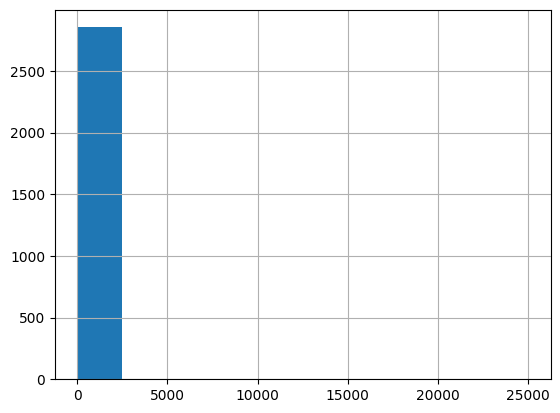

In [4]:
print(df['price'].min(), df['price'].max())
df['price'].hist();

Looks quite skewed! We're going to focus on Airbnb listings priced between 50 and 1500 dollars (both included).

👉 Create a DataFrame named `reduced` with only listings priced between 50 and 1500.

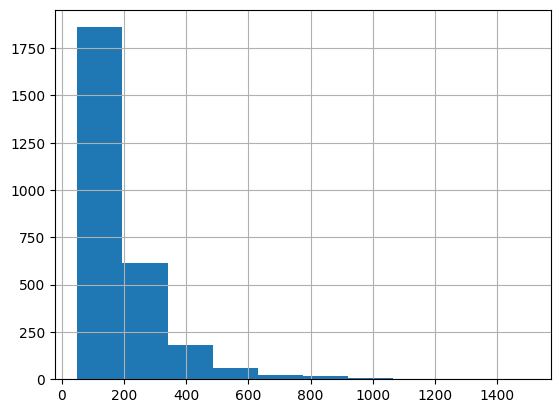

In [5]:
reduced = df[(df['price'] >= 50) & (df['price'] <= 1500)].copy()
reduced['price'].hist();

#### Check your code

In [6]:
from nbresult import ChallengeResult

result = ChallengeResult('reduced',
    reduced_min=reduced['price'].min(),
    reduced_max=reduced['price'].max(),
    reduced_shape=reduced.shape
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_reduced.py::TestReduced::test_reduced_has_the_right_shape PASSED    [ 50%]
test_reduced.py::TestReduced::test_reduced_min_max PASSED                [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/reduced.pickle

git commit -m 'Completed reduced step'

git push origin master



### Clean other columns

👉 Inspect your `reduced` DataFrame. 

There are two columns that we will need to change a bit before we start our modeling. Do you see which ones and why?
<br><br>
<details><summary><i>💡  Solution</i></summary>

- The `bathrooms_text` column seems to have mainly numeric information, but in a text format.
- The `instant_bookable` column has `t` and `f` values. It would be easier for us to have just 1s and 0s instead.
</details>


Let's start with the first problematic column. 

👉 Have a look at the unique values in the column.

In [7]:
reduced['bathrooms_text'].unique()

array(['1 bath', '2.5 shared baths', '1 shared bath', '1.5 baths',
       '1 private bath', '2.5 baths', '2 baths', '2 shared baths',
       '3.5 baths', '3 baths', '1.5 shared baths', '4 baths',
       '0 shared baths', '4.5 baths', '0 baths', '5 baths', 'Half-bath',
       '7 baths', '6 baths', '5.5 baths'], dtype=object)

Here is the cleaning function (a little 🎁 for you), but you will have to _apply_ it to the DataFrame yourself.

In [8]:
def extract_number(text):
    if text.lower() == "half-bath":
        return 0.5
    else:
        return float(text.split(' ')[0])

👉 Use the function to clean the column, and save the result back in the same column.

In [9]:
reduced['bathrooms_text'] = reduced['bathrooms_text'].apply(extract_number)

Now, let's work on the other column. There are multiple ways to transform the values into 0s and 1s. 

👉 Pick the one you're comfortable with (as long as it's not a for loop...) and use it to clean the column.
<br><br>
<details><summary><i>💡  Hint</i></summary>
    
- [`pandas.Series.map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html) with a mapping dictionary
- [`pandas.Series.apply()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) with a lambda function (not recommended on large datasets because it is slow)
- [`numpy.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html)
- Boolean indexing
</details>

In [10]:
## Different methods

# .map with a dict
reduced['instant_bookable'].map({'t': 1, 'f': 0})

# .apply with a lambda
reduced['instant_bookable'].apply(lambda x: 1 if x == 't' else 0)

# np.where
import numpy as np
np.where(reduced['instant_bookable'] == 't', 1, 0)

# boolean indexing
(reduced['instant_bookable'] == 't').astype(int)



## Pick one and assign
reduced['instant_bookable'] = (reduced['instant_bookable'] == 't').astype(int)

#### Check your code

In [11]:
from nbresult import ChallengeResult

result = ChallengeResult('cleaned',
    reduced_shape=reduced.shape,
    bathrooms_text_dtype=reduced['bathrooms_text'].dtype,
    instant_bookable_dtype=reduced['instant_bookable'].dtype,

)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_cleaned.py::TestCleaned::test_bathrooms_text_dtype PASSED           [ 33%]
test_cleaned.py::TestCleaned::test_cleaned_has_the_right_shape PASSED    [ 66%]
test_cleaned.py::TestCleaned::test_instant_bookable_dtype PASSED         [100%]

============================== 3 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/cleaned.pickle

git commit -m 'Completed cleaned step'

git push origin master



### Make a reusable function

Great! We have done all the cleaning. But what if later we want to do this for another CSV file?

👉 Create a `df_load_and_clean` function that combines all the previous steps. If all goes well, you should not be doing much more than just copy-pasting from what you did before.

In [12]:
def df_load_and_clean(url):
    '''Loads a CSV from the `url` provide and does the basic cleaning
    '''
    # Read the CSV into a dataframe
    # $DELETE_BEGIN
    df = pd.read_csv(url, index_col=0)
    # $DELETE_END

    # Clean and convert price into a float
    # $DELETE_BEGIN
    df['price'] = df['price'].str.replace("$", "", regex=False) \
                         .str.replace(",", "", regex=False) \
                         .astype(float)
    # $DELETE_END

    # Keep only prices between 50 and 1500
    # $DELETE_BEGIN
    reduced = df[(df['price'] >= 50) & (df['price'] <= 1500)].copy()
    # $DELETE_END

    # Clean and convert bathrooms_text into a float
    # $DELETE_BEGIN
    reduced['bathrooms_text'] = reduced['bathrooms_text'].apply(extract_number)
    # $DELETE_END

    # Convert instant_bookable into 0s and 1s
    # $DELETE_BEGIN
    reduced['instant_bookable'] = (reduced['instant_bookable'] == 't').astype(int)
    # $DELETE_END

    # Return the result
    # $DELETE_BEGIN
    return reduced
    # $DELETE_END

#### Check your code 

In [13]:
new_df = df_load_and_clean(url)

In [14]:
from nbresult import ChallengeResult

result = ChallengeResult('load_and_clean',
    new_df=new_df,
    new_shape=new_df.shape,
    price_dtype=new_df['price'].dtype,
    bathrooms_text_dtype=new_df['bathrooms_text'].dtype,
    instant_bookable_dtype=new_df['instant_bookable'].dtype
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 5 items

test_load_and_clean.py::TestLoadAndClean::test_bathrooms_text_dtype PASSED [ 20%]
test_load_and_clean.py::TestLoadAndClean::test_cleaned_has_the_right_shape PASSED [ 40%]
test_load_and_clean.py::TestLoadAndClean::test_instant_bookable_dtype PASSED [ 60%]
test_load_and_clean.py::TestLoadAndClean::test_price_has_the_right_dtype PASSED [ 80%]
test_load_and_clean.py::TestLoadAndClean::test_return PASSED             [100%]

============================== 5 passed in 0.02s ===============================


💯 Y

Great! You now have a function that loads the data for you, and does the cleaning for you. Time to go to the next step!

## 2. Train-Test Split 🚦

### Select the relevant columns

Look at the columns and pick only the ones that can help us with our linear regression task. 

Hint: some columns really won't have added value for our regression task. Drop those.

👉 Create `X` and `y` starting from `new_df`

In [15]:
new_df.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'availability_365', 'instant_bookable', 'id', 'listing_url',
       'scrape_id', 'last_scraped', 'name', 'description'],
      dtype='object')

In [16]:
remove_columns = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'description']

X = new_df.drop(columns=(remove_columns + ['price']))
y = new_df['price']

#### Check your code

In [17]:
from nbresult import ChallengeResult

result = ChallengeResult('x_and_y',
    x_shape=X.shape,
    y_shape=y.shape,
    x_columns=X.columns
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_x_and_y.py::TestXAndY::test_excluded_columns PASSED                 [ 25%]
test_x_and_y.py::TestXAndY::test_target_not_in_x PASSED                  [ 50%]
test_x_and_y.py::TestXAndY::test_x_has_the_right_shape PASSED            [ 75%]
test_x_and_y.py::TestXAndY::test_y_has_the_right_shape PASSED            [100%]

============================== 4 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/x_and_y.pickle

git commit -m 'Completed x_and_y step'

git pu

### Split in train and test set

👉 Split your data in a train and a test set.

Let's do a 80/20 split.

And let's use a random state of `42`. (In your final pipeline you'd want to remove the random state, but here it will help us to compare our results.)

In [18]:
from sklearn.model_selection import train_test_split

# $CHALLENGIFY_BEGIN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# $CHALLENGIFY_END

## 3. Preprocessing 👷

We already did some basic cleaning, but we'll need some preprocessing steps. Let's do those using `scikit-learn`. We will immediately do our preprocessing using pipelines.

❓ Why do we want to use pipelines?

<details>
  <summary><i>Answer</i>
  </summary>

  1. They allow us to structure our preprocessing nicely
  2. They make it easy to fit our preprocessing to the training set and to transform the training set, the test set, and any new data we want to feed into our model
  3. They will allow us to properly cross-validate and grid search a full pipeline with preprocessing and model

</details>

By default preprocessors output NumPy arrays. We prefer to output Pandas DataFrames because they are easier to work with.

You can use the `.set_output(transform='pandas')` method of your transformer to keep the output in a DataFrame format instead of a numpy array.

💡 But instead of doing that for each transformer, you can also set this globally. Run the cell below.

In [19]:
from sklearn import set_config
set_config(transform_output="pandas")

### Numeric features

👉 Create a list with the numeric features

In [20]:
# Tip: print your columns and then copy-paste them to form your new list
# It's easier to remove columns from a list than to type (and fix typos)
X_train.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'availability_365', 'instant_bookable'],
      dtype='object')

In [21]:
num_cols = [] # YOUR LIST HERE

In [22]:
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365']

#### Missing values

👉 Examine the missing values. How many columns have missing values? How many values are missing?

In [23]:
X_train.isnull().sum() / X_train.count()

neighbourhood_cleansed    0.000000
latitude                  0.000000
longitude                 0.000000
property_type             0.000000
room_type                 0.000000
accommodates              0.000000
bathrooms_text            0.000000
bedrooms                  0.055344
beds                      0.007286
minimum_nights            0.000000
number_of_reviews         0.000000
review_scores_rating      0.071186
availability_365          0.000000
instant_bookable          0.000000
dtype: float64

We'll have to do something about these missing values. Which strategies can you apply?
<br><br>
<details><summary><i>💡  Solution</i></summary>

- **Drop the columns** with missing values, but we only have a small percentage of missing values. So let's not do that.
- **Drop the rows** with missing values. Quick and dirty, but for most columns we actually have the values. So let's not do that.
- **Impute missing values**: fill in the blanks.
</details>

Look at the columns with missing values. What would be the best imputation strategy for each? Check each column's unique values to make up your mind.
<br><br>
<details><summary><i>💡  Solution</i></summary>

- `bedrooms`: if there is no data, we could assume there is no separate bedroom. So impute with 0s.
- `beds`: if there is no data, we could assume there are no beds. So impute with 0s.
- `review_scores_rating`: if there is no data, we could assume that there is no rating yet, and we could impute with the average rating. (You could make a case for other strategies in this case. A [`KNNImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) could be interesting here, but we'll stick to our simple imputing strategy for now.)
</details>

In [24]:
X_train.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable
2198,28806,35.575588,-82.575706,Entire rental unit,Entire home/apt,4,1.0,2.0,2.0,3,43,4.98,36,0
2804,28806,35.569290,-82.612050,Entire home,Entire home/apt,6,2.0,4.0,5.0,30,0,NaN,45,0
2307,28806,35.592520,-82.612850,Entire home,Entire home/apt,5,1.5,3.0,3.0,30,0,NaN,325,1
273,28715,35.514620,-82.650800,Entire cottage,Entire home/apt,7,1.0,3.0,3.0,1,529,4.72,192,1
2132,28715,35.554130,-82.650110,Private room in home,Private room,3,1.0,1.0,1.0,1,109,4.97,147,1


👉 Let's prepare our imputers.

Because we have two different strategies, you'll need two separate imputers: one for the 0 imputation, and one for the mean imputation!

Name them `zero_imputer` and `mean_imputer`.

In [25]:
from sklearn.impute import SimpleImputer

In [26]:
# Instantiate your zero_imputer and mean_imputer
zero_imputer = SimpleImputer(strategy="constant")
mean_imputer = SimpleImputer(strategy="mean")

# Make two lists zero_imputer_cols and mean_imputer_cols
# Each list should contain the column names that will be zero / mean imputed
# This will come in handy later when we will create our pipeline
zero_imputer_cols = ['bedrooms', 'beds']
mean_imputer_cols = ['review_scores_rating']

Now, we can combine our two imputers in a column transformer as a first step in our pipeline.

👉 Make a column transformer called `num_imputer` to :
- zero impute the columns we defined above
- mean impute all other columns unchanged (hint: think of the `remainder` parameter)

(The other columns didn't have missing values, but we might use our pipeline for other cities too. That's why we'll mean impute all other columns for now.)

You can choose between using the class based approach (`Pipeline`, `ColumnTransformer`) or the `make_pipeline`, `make_column_transformer` shortcut functions.

In [27]:
from sklearn.compose import ColumnTransformer, make_column_transformer

# Create num_imputer
# $CHALLENGIFY_BEGIN
num_imputer = ColumnTransformer(
    [('zero_imputer', zero_imputer, zero_imputer_cols)],
    remainder=mean_imputer
)
# $CHALLENGIFY_END

# Display num_imputer to check
num_imputer

ColumnTransformer(remainder=SimpleImputer(),
                  transformers=[('zero_imputer',
                                 SimpleImputer(strategy='constant'),
                                 ['bedrooms', 'beds'])])

#### Scale the numerical features

👉 Which columns do you need to scale?

Also check the distributions to see which scaler to choose. 👉 Run the cell below.

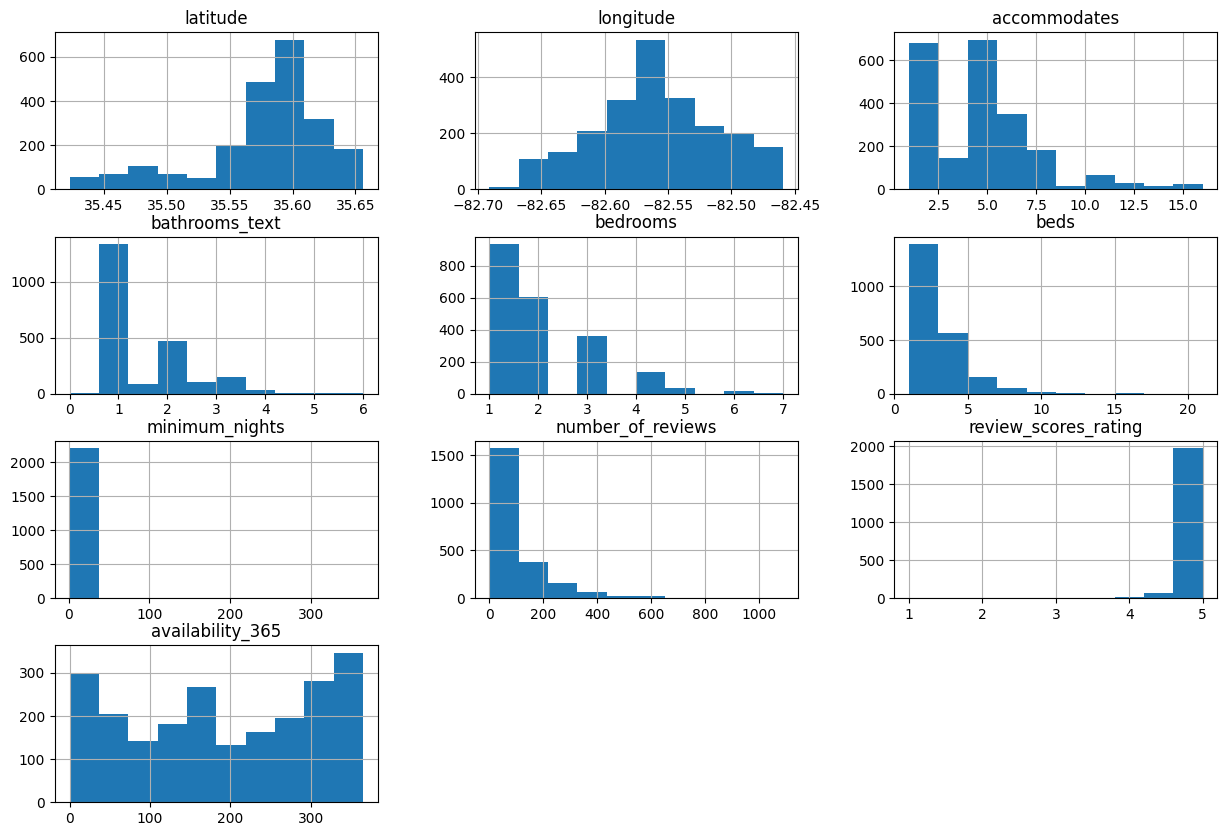

In [28]:
X_train[num_cols].hist(figsize=(15,10));

👉 Instantiate an appropriate scaler. For now, to go fast, we'll scale all our selected columns with a RobustScaler. Later we should come back to this step, and choose the most appropriate scaler for each column.



In [29]:
from sklearn.preprocessing import RobustScaler

# Instantiate your scaler. Call it `scaler`
# Pro tip: use the .set_output(transform='pandas') method
# $CHALLENGIFY_BEGIN
scaler = RobustScaler()
# $CHALLENGIFY_END

We have created an imputer for our numerical features, and a scaler. We can now create a pipeline to combine both steps.

👉 Make a pipeline called `num_pipe` to :
- impute missing values using our `num_imputer`
- scale features using our `scaler`

You can choose between using the class based approach (`Pipeline`, `ColumnTransformer`) or the `make_pipeline`, `make_column_transformer` shortcut functions.

In [30]:
from sklearn.pipeline import Pipeline, make_pipeline

# Create num_pipe:
# It should first use your num_imputer and then your scaler
# $CHALLENGIFY_BEGIN
num_pipe = make_pipeline(
    num_imputer,
    scaler
)
# $CHALLENGIFY_END

# Display num_pipe to check your pipeline
num_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=SimpleImputer(),
                                   transformers=[('zero_imputer',
                                                  SimpleImputer(strategy='constant'),
                                                  ['bedrooms', 'beds'])])),
                ('robustscaler', RobustScaler())])

#### Check your code

In [31]:
from nbresult import ChallengeResult

result = ChallengeResult('scaler',
    num_cols=num_cols,
    X_train_scaled=num_pipe.fit_transform(X_train[num_cols])
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_scaler.py::TestScaler::test_columns_numeric PASSED                  [ 50%]
test_scaler.py::TestScaler::test_has_the_right_shape PASSED              [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/scaler.pickle

git commit -m 'Completed scaler step'

git push origin master



### One Hot Encode the categorical features

👉 Which columns do you need to encode?

In [32]:
cat_cols = [] # YOUR LIST HERE

In [33]:
cat_cols = ['neighbourhood_cleansed', 'property_type', 'room_type', 'instant_bookable']

Good practice: check how many different values you have in each of the columns.

👉 Run the cell below to have a look.

Remember that every value will become a column in our X after the encoding.

In [34]:
for col in cat_cols:
    display(pd.DataFrame(X_train[col].value_counts()))

,neighbourhood_cleansed
28806,618
28801,511
28804,306
28803,296
28805,210
28704,152
28715,64
28732,55


,property_type
Entire home,732
Entire rental unit,292
Entire guest suite,283
Private room in home,157
Entire condo,137
Entire cabin,87
Entire cottage,86
Entire guesthouse,81
Entire bungalow,64
Entire townhouse,45


,room_type
Entire home/apt,1934
Private room,267
Hotel room,10
Shared room,1


,instant_bookable
1,1289
0,923


It's clear that for one of these columns we'll have to be a bit smart when encoding. Otherwise we'll have way too many columns in our end result.

👉 Find the right parameter for the OneHotEncoder to limit the number of created columns.
<br><br>
<details><summary><i>💡  Solution</i></summary>
There are two candidates:
<ul>
    <li><strong>max_categories</strong>
    </li>
    <li><strong>min_frequency</strong>
    </li>
</ul>
    Let's use <code>max_categories=10</code> for our first iteration. We can change this later.
</details>

👉 Now create a one hot encoder for your categorical features

In [35]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate your OneHotEncoder. Call it `encoder`
# Use the .set_output() method again!
# $CHALLENGIFY_BEGIN
encoder = OneHotEncoder(
    max_categories=10,
    handle_unknown='ignore',
    drop='if_binary',
    sparse_output=False
)
# $CHALLENGIFY_END

We have created a OneHotEncoder for our categorical features.

Because we didn't have any missing values for our categorical features, that was enough for our case. But remember: we might use our pipeline for other cities too. So it's better to add an imputer for missing values.

👉 Make a pipeline called `cat_pipe` to :
- impute missing values with the most frequent value
- scale features using our `scaler`

Use a different approach than you used in your `num_pipe` (class based vs shortcut function)

In [36]:
from sklearn.pipeline import Pipeline, make_pipeline

# Create cat_pipe:
# It should first apply an imputer and then your scaler
# $CHALLENGIFY_BEGIN
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_pipe = Pipeline([
    ('cat_imputer', cat_imputer),
    ('OHE', encoder)
])
# $CHALLENGIFY_END

# Display cat_pipe to check your pipeline
cat_pipe

Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')),
                ('OHE',
                 OneHotEncoder(drop='if_binary', handle_unknown='ignore',
                               max_categories=10, sparse_output=False))])

#### Check your code

In [37]:
from nbresult import ChallengeResult

result = ChallengeResult('encoder',
    cat_cols=cat_cols,
    X_train_encoded=cat_pipe.fit_transform(X_train[cat_cols])
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_encoder.py::TestEncoder::test_columns_categorical PASSED            [ 50%]
test_encoder.py::TestEncoder::test_has_the_right_shape PASSED            [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/encoder.pickle

git commit -m 'Completed encoder step'

git push origin master



### Bringing numerical and categorical features back together

We have a pipeline for the numerical and a one-hot-encoder for the categorical features. Let's bring them together.

👉 Make a new column transformer called `preprocessor` that will pipe the numerical features through our `num_pipe`, and the categorical features through our `cat_pipe`.

If in the previous step you used the class based approach (`Pipeline`, `ColumnTransformer`), then switch to the `make_pipeline`, `make_column_transformer` shortcut functions this time. Or the other way around. Just make sure you switch 🙃

In [38]:
# Create preprocessor:
# Use num_pipe for the num_cols and cat_pipe for the cat_cols
# $CHALLENGIFY_BEGIN
preprocessor = make_column_transformer(
    (num_pipe, num_cols),
    (cat_pipe, cat_cols)
)
# $CHALLENGIFY_END

# Display preprocessor to check your pipeline
preprocessor

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('columntransformer',
                                                  ColumnTransformer(remainder=SimpleImputer(),
                                                                    transformers=[('zero_imputer',
                                                                                   SimpleImputer(strategy='constant'),
                                                                                   ['bedrooms',
                                                                                    'beds'])])),
                                                 ('robustscaler',
                                                  RobustScaler())]),
                                 ['latitude', 'longitude', 'accommodates',
                                  'bathrooms_text', 'bedrooms', 'beds',
                                  'minimum_nights', 'number_of_reviews',
                                  'review_scores_rating', 'availability_365']),
                                ('pipeline-2',
                                 Pipeline(steps=[('cat_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('OHE',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                max_categories=10,
                                                                sparse_output=False))]),
                                 ['neighbourhood_cleansed', 'property_type',
                                  'room_type', 'instant_bookable'])])

Do you see the difference between using the class based approach and the `make_***` shortcut functions? 

The class based approach let's you define nice names for the different steps. If you use `make_***`, scikit-learn will determine the name for you. This becomes especially visible when using `ColumnTransformer`.

Let's recap what we did:


- For the **numerical** columns (our `num_cols`):
  - Firstly, we imputed missing values using our imputers:
    - `zero_imputer` for features `bedrooms` and `beds`
    - `mean_imputer` for features `review_scores_rating`
    - The other columns did not have any missing values, but because we are going to use our preprocessor also for other cities, we put all of them also through the `mean_imputer`
  - Secondly, we scaled all numerical features with our `scaler`
  
  
-  For the **categorical** columns (our `cat_cols`):
   - Impute missing values. We didn't have any in our data, but again we want it to work for other cities too. We impute the most frequent value.
   - Encode with our `encoder`
  
A visual summary of what our pipeline looks like:

<img alt="Pipeline schema" src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/ml-reboot-pipeline.png" width=700>


Let's use our pipeline to preprocess our train and test sets.

Store them in X_train_preprocessed and X_test_preprocessed.

You will probably run into a couple of errors. Most probably they come from the OneHotEncoder. Up to you to find the right parameters for your OneHotEncode and change them above.

In [39]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
X_train_preprocessed.shape, X_test_preprocessed.shape

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


((2212, 33), (554, 33))

If you get a UserWarning about unknown categories when preprocessing the test set: that is normal. Do you know why?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    Remember our OneHotEncoder?
    <br>
    It encodes all the categories in the train set into columns with 1s and 0s.
    <br>
    It's possible that the encoder will encounter categories in the test set that it hasn't seen during the fit. For those rows, all encoded columns will contain 0s (because we chose <code>handle_unknown='ignore'</code>).
</details>

#### Check your code

In [40]:
from nbresult import ChallengeResult

result = ChallengeResult('pipeline',
    X_train_preprocessed=X_train_preprocessed,
    X_test_preprocessed=X_test_preprocessed,
    X_train_to_test_pipeline=preprocessor.fit_transform(X_train),
    X_test_to_test_pipeline_not_fitted_on_test=preprocessor.transform(X_test),
)
result.write()

print(result.check())

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_pipeline.py::TestPipeline::test_has_the_right_shape PASSED          [ 33%]
test_pipeline.py::TestPipeline::test_test_was_only_transformed PASSED    [ 66%]
test_pipeline.py::TestPipeline::test_train_was_transformed PASSED        [100%]

============================== 3 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/pipeline.pickle

git commit -m 'Completed pipeline step'

git push origin master



🚀 Congratulations! You built your complete preprocessing pipeline.

## 4. Modelling 📈

Now that we have a pipeline to preprocess our data, we can finally get into modelling.

We will use the [`ElasticNet`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet) linear regression model, that will give us some parameters to play with in the next phase 🎯. 

Do you remember what the ElasticNet model is?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    ElasticNet is a linear regreession, with a mixture of L1 and L2 regularization. It basically combines Ridge and Lasso regression.
</details>

👉 Instantiate an ElasticNet model and call it `elastic`

In [41]:
from sklearn.linear_model import ElasticNet

# Instantiate a model and call it `elastic`
# $CHALLENGIFY_BEGIN
elastic = ElasticNet()
# $CHALLENGIFY_END

Now we want to obtain a cross validated score.

Have a look at the cell below, and run the cell.

In [42]:
from sklearn.model_selection import cross_val_score

cv_results = cross_val_score(elastic, X_train_preprocessed, y_train, cv=5)
cv_results.mean()

0.510983252983251

**But we did something wrong! 😱**

👉 Take a moment to think where we made a mistake in the cell above before you read further.
<br><br>
<details><summary><i>💡  Solution</i></summary>
When we cross-validated, we only cross-validated the modeling step.

In the cross-validation, our training set is split again in a train and a validation set (and that 5 times in our case).

But our preprocessing steps were applied to the whole training set, **before** this second split. 
    
This means that we have data leakage between our train and validation set inside the cross-validation.

Ideally, for every fold of our cross-validation, we want to:

  - Fit all preprocessing steps on the train set
  - Transform the train and the validation set
  - Train the model on the train
  - Score on the validation set

The cross-validation we did so far, did not correctly do the preprocessing.
</details>

👉 How could we solve this? Take a moment to think about it.
<br><br>
<details><summary><i>💡  Solution</i></summary>
We could make a pipeline with all our preprocessing steps + our model, and cross-validate this full pipeline instead of just the model.
    
That way, the cross-validation will each time fit the preprocessor and the model only on the training set.
</details>

👉 Create an `elastic_pipe` by combining your `preprocessing` pipeline with the `elastic` model

In [43]:
# Create a pipeline with your preprocessor and your model
# Call it `elastic_pipe`
# $CHALLENGIFY_BEGIN
elastic_pipe = make_pipeline(preprocessor, elastic)
# $CHALLENGIFY_END

# Display elastic_pipe to check your pipeline
elastic_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('columntransformer',
                                                                   ColumnTransformer(remainder=SimpleImputer(),
                                                                                     transformers=[('zero_imputer',
                                                                                                    SimpleImputer(strategy='constant'),
                                                                                                    ['bedrooms',
                                                                                                     'beds'])])),
                                                                  ('robustscaler',
                                                                   RobustScaler())]),
                                                  ['latitude', 'longitude',
                                                   'accommodates',
                                                   'bathrooms_text', 'bedroo...
                                                   'number_of_reviews',
                                                   'review_scores_rating',
                                                   'availability_365']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OHE',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 max_categories=10,
                                                                                 sparse_output=False))]),
                                                  ['neighbourhood_cleansed',
                                                   'property_type', 'room_type',
                                                   'instant_bookable'])])),
                ('elasticnet', ElasticNet())])

We can now use this pipeline in our modelling steps.

👉 Cross-validate `elastic_pipe` and store your average score in `cv_score`

Remember we don't need to separately preprocess our training data. Because we combined preprocessing and model into one pipeline, scikit-learn will do the preprocessing for us.

In [44]:
# Cross-validate it on your training set
# $CHALLENGIFY_BEGIN
cv_results = cross_val_score(elastic_pipe, X_train, y_train, cv=5)
# $CHALLENGIFY_END

# Save the average score in a variable `cv_score`
# $CHALLENGIFY_BEGIN
cv_score = cv_results.mean()
cv_score
# $CHALLENGIFY_END

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown catego

0.5102770632191647

You might get a few UserWarnings about unknown categories. That is normal. Do you remember why?
<br><br>
<details><summary><i>💡  Answer</i></summary>

Remember our OneHotEncoder?

It encodes all the categories in the train set into columns with 1s and 0s.
    
It can happen that in the validation set the encoder encounters categories that it hasn't seen during the fit. In that cases all encoded columns will have 0s (because we chose `handle_unknown='ignore'`.

We get multiple warnings: one for each fold where this happens.
</details>

#### Check your code

In [45]:
from nbresult import ChallengeResult

result = ChallengeResult('linreg_pipe',
    cv_score=cv_score
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_linreg_pipe.py::TestLinregPipe::test_cv_score PASSED                [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/linreg_pipe.pickle

git commit -m 'Completed linreg_pipe step'

git push origin master



Back to our results.

What does this `cv_score` represent? What metric are we using here? Are you happy with this score?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    For regression models, the default score in scikit-learn is the R<sup>2</sup>.<br>
    To know if this is good, we need a baseline.
</details>

Let's create a baseline model. What would a good baseline be for this task?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    For regression models, the simplest thing we can do is to simply use the mean as the prediction.
</details>

To compare our baseline model, we should also cross-validate it, just like our real model. 

This is where scikit-learn's [dummy models](https://scikit-learn.org/stable/api/sklearn.dummy.html) come in handy. They provide us with a way to use a simple mean calculation as a real scikit-learn model.

👉 Have a look at the cell below, and figure out what we're doing.

In [46]:
from sklearn.dummy import DummyRegressor

# Create a baseline_pipe using the baseline model
baseline_pipe = make_pipeline(
    preprocessor,
    DummyRegressor(strategy='mean')
    )

# Cross-validate on the preprocessed training set
baseline_cv_results = cross_val_score(baseline_pipe, X_train, y_train, cv=5)

# Save the average score in a variable `cv_score`
baseline_cv_score = baseline_cv_results.mean()
baseline_cv_score

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown catego

-0.002110600285393893

Is our model performing better than the baseline?

👉 Save your answer "yes" or "no" in a variable `better_than_baseline`.

In [47]:
better_than_baseline = None # Choose between "yes" or "no"

In [48]:
better_than_baseline = "yes"

#### Check your code

In [49]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline_model',
    better_than_baseline=better_than_baseline
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_baseline_model.py::TestBaselineModel::test_is_better_than_baseline PASSED [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/baseline_model.pickle

git commit -m 'Completed baseline_model step'

git push origin master



Now that we are this far, it's time to take a step back.

What did we do so far:
- We created a function `df_load_and_clean()` to **load our data and do some basic cleaning**
- We **split** our data in train and test sets
- We created a **preprocessor** using pipelines:
  - Imputing missing values
  - Scaling numerical features
  - Encoding categorical features
  - Combine numerical and categorical features back in one big preprocessed DataFrame
- We instantiated a **model** and added it to the pipeline
- We **cross-validated** the whole pipeline
- We compared our model to a **baseline** model (taking the mean)

## 5. Fine-Tuning 🎯 

With pipelines, we can now start fine-tuning the complete pipeline


In our pipeline we use the ElasticNet model. What are the hyperparameters we can tune? Have a look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet).
<br><br>
<details><summary><i>💡  Solution</i></summary>

`alpha`: the amount of regularization we want

`l1_ratio`: how much L1 regularization we want (the rest will be L2)
</details>

👉 Fine-tune your `elastic_pipe` and store the result in `pipe_grid_score`

In [50]:
# First find the name of the correct parameter to tune
elastic_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('pipeline-1',
                                    Pipeline(steps=[('columntransformer',
                                                     ColumnTransformer(remainder=SimpleImputer(),
                                                                       transformers=[('zero_imputer',
                                                                                      SimpleImputer(strategy='constant'),
                                                                                      ['bedrooms',
                                                                                       'beds'])])),
                                                    ('robustscaler',
                                                     RobustScaler())]),
                                    ['latitude', 'longitude', 'accommodates',
                                     'bathrooms_text', 'bedrooms', 'beds',
           

In [51]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Let's suppress those UserWarnings we talked about before.
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Instantiate a hyperparameter grid with these values:
#     'alpha': [0.1, 1.0, 10.0]
#     'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
# $CHALLENGIFY_BEGIN
grid = {
    'elasticnet__alpha': [0.01, 0.1, 1.0],
    'elasticnet__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
}
# $CHALLENGIFY_END

# Instantiate a GridSearchCV with linreg_pipe and your hyperparameter grid
# $CHALLENGIFY_BEGIN
search = GridSearchCV(elastic_pipe, grid)
# $CHALLENGIFY_END

# Fit the grid search on X_train, y_train
# $CHALLENGIFY_BEGIN
search.fit(X_train, y_train)
# $CHALLENGIFY_END

GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('columntransformer',
                                                                                          ColumnTransformer(remainder=SimpleImputer(),
                                                                                                            transformers=[('zero_imputer',
                                                                                                                           SimpleImputer(strategy='constant'),
                                                                                                                           ['bedrooms',
                                                                                                                            'beds'])])),
                                                                                         ('robustscaler',
                                                                                          RobustScaler())]),
                                                                         ['latitude',
                                                                          'longitude',
                                                                          'accommodates',
                                                                          '...
                                                                         Pipeline(steps=[('cat_imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('OHE',
                                                                                          OneHotEncoder(drop='if_binary',
                                                                                                        handle_unknown='ignore',
                                                                                                        max_categories=10,
                                                                                                        sparse_output=False))]),
                                                                         ['neighbourhood_cleansed',
                                                                          'property_type',
                                                                          'room_type',
                                                                          'instant_bookable'])])),
                                       ('elasticnet', ElasticNet())]),
             param_grid={'elasticnet__alpha': [0.01, 0.1, 1.0],
                         'elasticnet__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]})

👉 Save the score of the best estimator in grid_best_score and display it

In [52]:
grid_best_score = search.best_score_
grid_best_score

0.5843100723467151

👉 Save the hyperparameters of the best estimator in grid_best_score and display them

In [53]:
grid_best_params = search.best_params_
grid_best_params

{'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.75}

👉 Finally, use the best model and score it on the test set, save it into `grid_test_score`

Do NOT train a new model, it's not needed: you can get it out of your grid search results!

In [54]:
grid_test_score = search.best_estimator_.score(X_test, y_test)
grid_test_score

0.46099147363991166

👉 How many models did the GridSearch train to get to its result?

Save your answer in a variable `nb_trainings`

In [55]:
training_count = 76

#### Check your code

In [56]:
from nbresult import ChallengeResult

result = ChallengeResult('grid_search',
    best_params=grid_best_params,
    best_score=grid_best_score,
    test_score=grid_test_score,
    training_count=training_count
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module05_MachineLearning/08-UnsupervisedLearning/Reboot_01-AirBnB-Prices/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_grid_search.py::TestGridSearch::test_best_params PASSED             [ 25%]
test_grid_search.py::TestGridSearch::test_best_score PASSED              [ 50%]
test_grid_search.py::TestGridSearch::test_test_score PASSED              [ 75%]
test_grid_search.py::TestGridSearch::test_training_count PASSED          [100%]

============================== 4 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/grid_search.pickle

git commit -m 'Completed grid_search step'

## How could we take this further?

You might have noticed that the grid search at the end was a bit basic.

And to be honest: finding better parameters is a bit of a challenge for this model. The models seems to be underfitting.

Extra things we could try out:

- **Feature engineering**: add extra features that can make your model perform better
  Some possibilities:
  - `price` divided by `bedrooms`
  - Calculate the distance from the city center (which you could approximate by the average of the latitude and longitude of all airbnb's)
  - To use those in your pipelines, you'll need to look into custom transformers (check the Workflow lecture)
- **Try out other models**: a `KNNRegressor` or an `SVR`
- **Grid search (or Randomized search) the hyperparameters of those models** (e.g. `n_neighbours`, `kernel`, `C`)
- **Add hyperparameters of the preprocessors to your grid search** (e.g. the imputation strategy)

**Don't do this for now, because we will be doing similar things in the next unit! 🚀**

🏁 Congratulations! You made it! You did a complete reboot of the Machine Learning workflow!

💾 Don't forget to `git add/commit/push` your notebook...